In [4]:
from pathlib import Path
from collections import Counter
import re
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sentencepiece as spm
from utils.BytePair import BPETok
from utils.CharTokenize import CharTokenizer
from tokenizers import models, Tokenizer, trainers
from tokenizers.pre_tokenizers import Whitespace

import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as op
from torch.distributions.categorical import Categorical

from natasha import (
    Segmenter,
    MorphVocab,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsEmbedding,
    Doc
)
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alexs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Pre-Processing Data

In [5]:
textPath = Path.cwd() / 'pre-book/BookInText/allTxt.txt'

with open(textPath, "r", encoding="utf-8") as file:
    text = file.read()

In [6]:
text = text.replace("ќ", "ъ")
text = text.replace("\xa0", " ")
text = text.replace("І", " ")
text = text.replace("\n", " ")
text = text.replace("\t", " ")

In [7]:
bad_chars = "#&*/123456789[]ї"

textList = text.split()
textList = [word for word in text.split() 
           if not any(char in bad_chars for char in word)]

In [8]:
text = ' '.join(textList)

In [8]:
setText = set(text)
setText

{' ',
 '!',
 '"',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 ':',
 ';',
 '?',
 '«',
 '»',
 'А',
 'Б',
 'В',
 'Г',
 'Д',
 'Е',
 'Ж',
 'З',
 'И',
 'К',
 'Л',
 'М',
 'Н',
 'О',
 'П',
 'Р',
 'С',
 'Т',
 'У',
 'Ф',
 'Х',
 'Ц',
 'Ч',
 'Ш',
 'Щ',
 'Ъ',
 'Ь',
 'Э',
 'Ю',
 'Я',
 'а',
 'б',
 'в',
 'г',
 'д',
 'е',
 'ж',
 'з',
 'и',
 'й',
 'к',
 'л',
 'м',
 'н',
 'о',
 'п',
 'р',
 'с',
 'т',
 'у',
 'ф',
 'х',
 'ц',
 'ч',
 'ш',
 'щ',
 'ъ',
 'ы',
 'ь',
 'э',
 'ю',
 'я',
 'ё',
 '–',
 '—',
 '’',
 '“',
 '”',
 '„',
 '…',
 '№'}

In [180]:
with open(Path.cwd() / "pre-book/BookInText/scaled_text.txt", "w", encoding="utf-8") as file:
    file.write(text)

## Mini-Analysis

Самым часто встречающимся символом по всем произведениям является - пробел, который встречается 1 045 813 млн. раз. \
Второй по частоте является символ - "о", встречается 581 908 раз. \
Третьим - "e" -> 457 190 раз. 

И не отстает буква "а" - 398 071 раз.

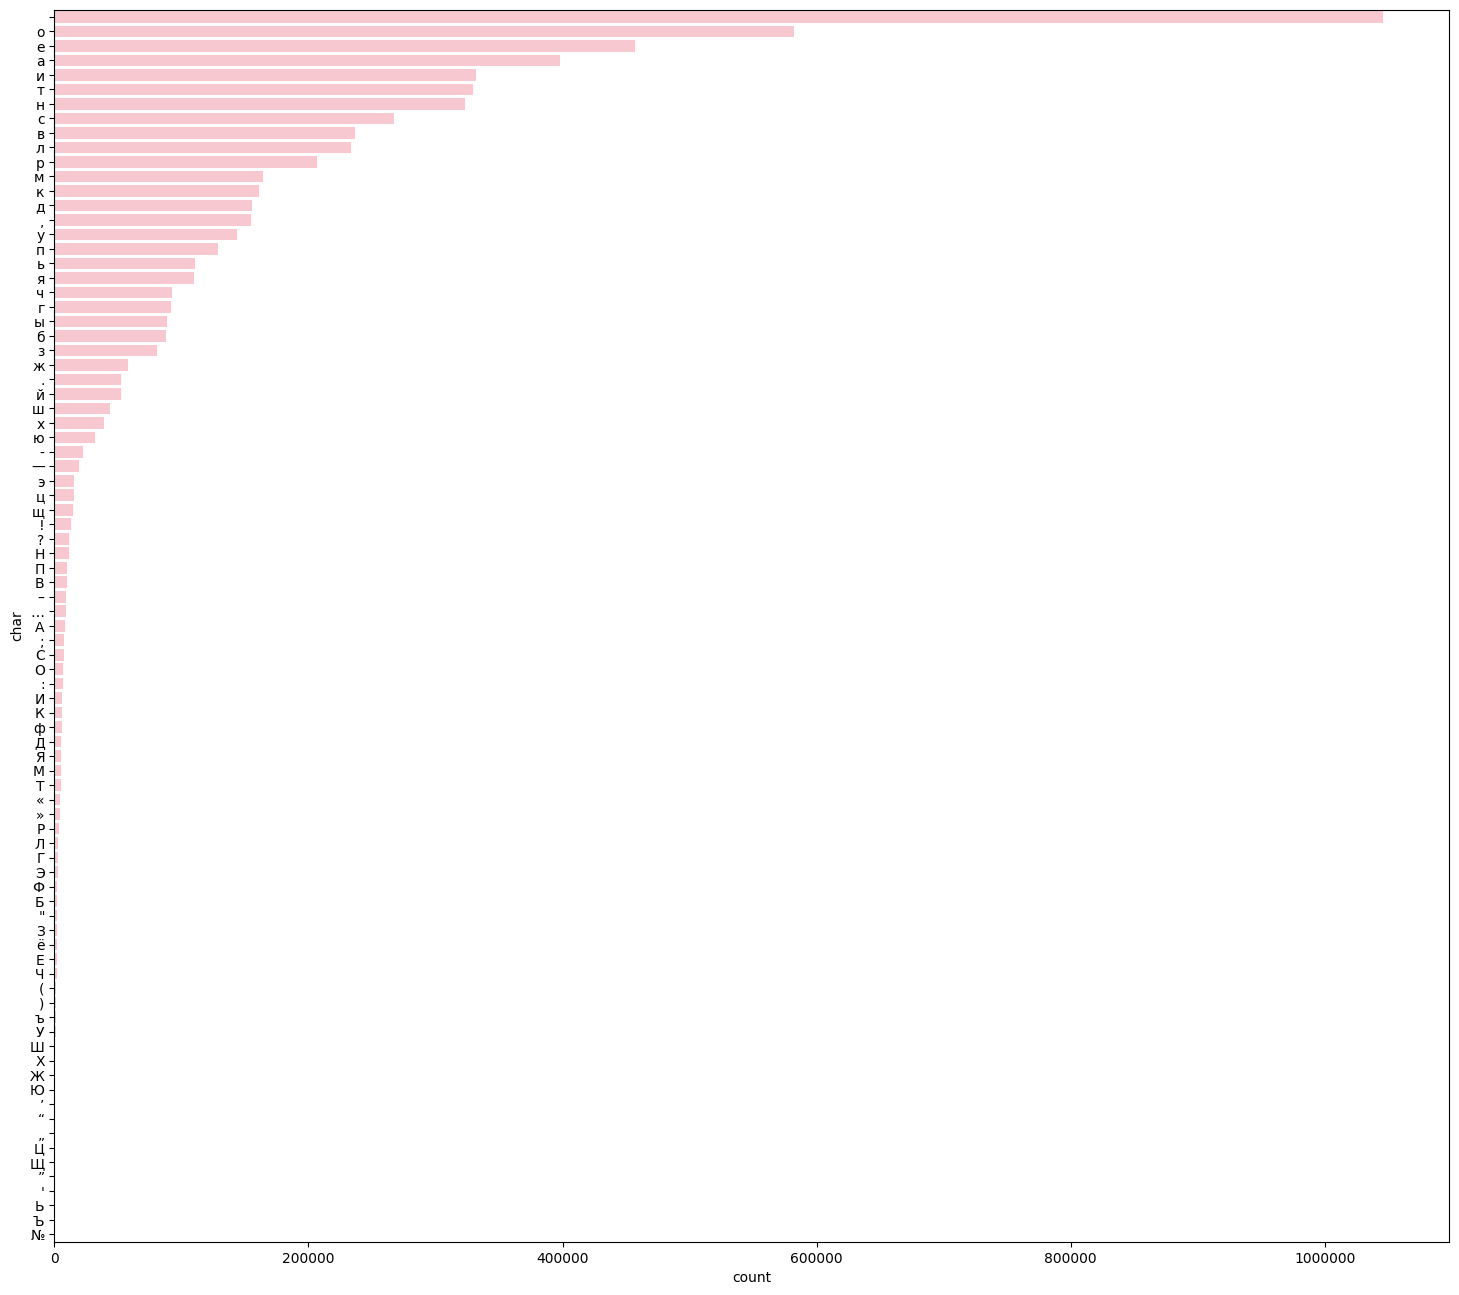

In [10]:
CharCount = dict(Counter([ch for ch in text]))
df_count = pd.DataFrame(CharCount.items(), columns=['char', 'count'])

df_count.sort_values('count', inplace=True, ignore_index=True, ascending=False)

plt.figure(figsize=(18, 16))
sns.set_color_codes("pastel")
sns.barplot(x="count", y="char", data=df_count, color='pink')
plt.ticklabel_format(style='plain', axis='x')

Самым частотным по длине словом являются слова с размером - 1. Далее - 3 и 2

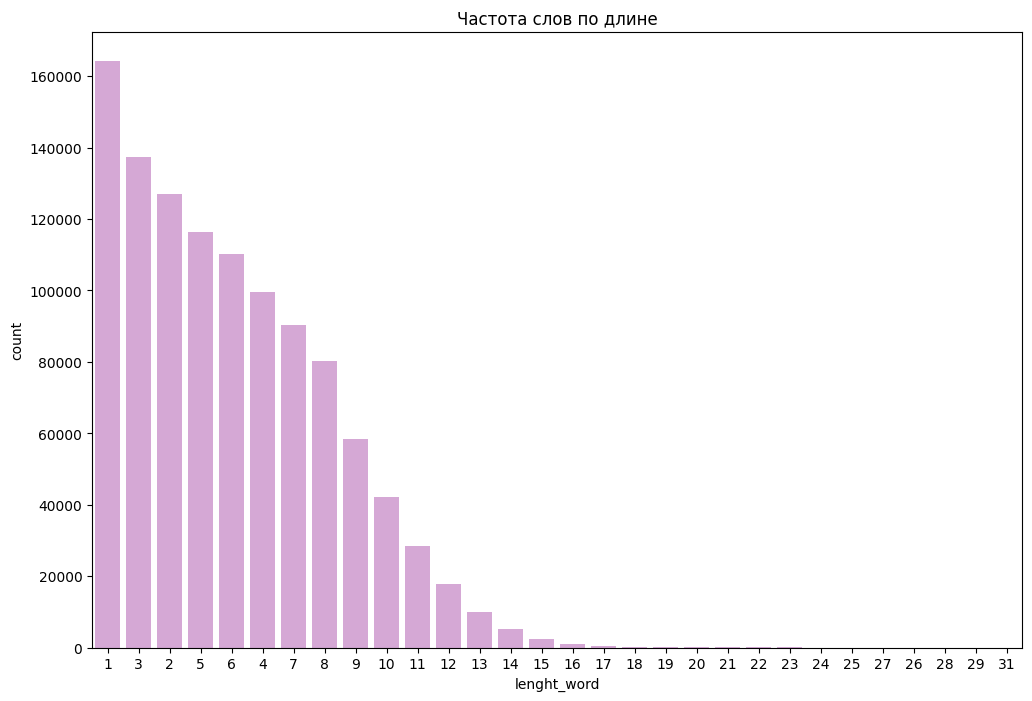

In [40]:
countLenWord = Counter()

words = text.split()

for word in words:
    countLenWord[len(word)] += 1
    
df_countLenWord = pd.DataFrame(list(countLenWord.items()), columns=['lenght_word', 'count'])
df_countLenWord.sort_values("count", inplace=True, ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x="lenght_word", y="count", data=df_countLenWord, order=df_countLenWord["lenght_word"].values, color='plum')
plt.title("Частота слов по длине")
plt.show()

In [55]:
boundShort = 7
boundLong = 8

N_short = df_countLenWord[df_countLenWord["lenght_word"] < boundShort]["count"].values.sum()
N_long = df_countLenWord[df_countLenWord["lenght_word"] > boundLong]["count"].values.sum()

ratio = round((N_short / N_long) * 100, 2)
print(N_short, N_long)
print(ratio)

755054 166531
453.4


Самым частотным словом является - "и". После идет - "не". А затем - "в"

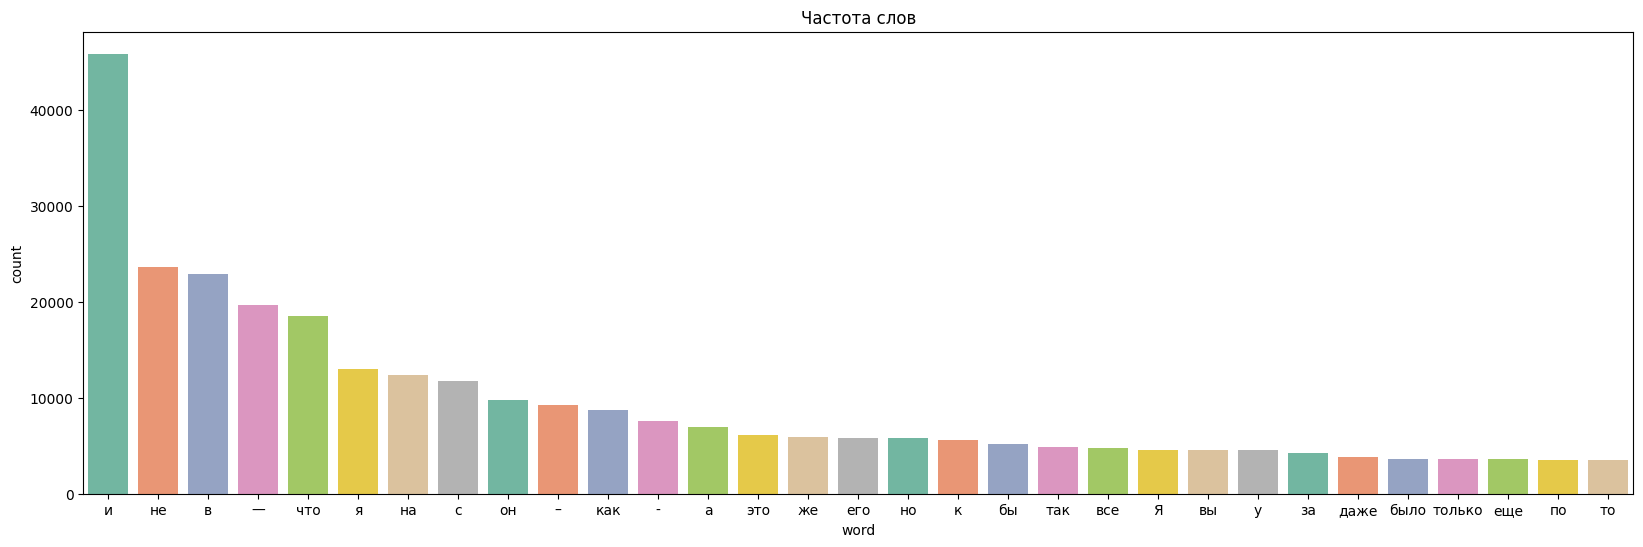

In [23]:
countWord = Counter()

words = text.split()

for word in words:
    countWord[word] += 1
    
df_countWord = pd.DataFrame(list(countWord.items()), columns=['word', 'count'])
df_countWord.sort_values("count", inplace=True, ascending=False)
plt.figure(figsize=(20, 6))
sns.barplot(x="word", y="count", data=df_countWord[:31], order=df_countWord["word"][:31].values, palette='Set2', hue="word")
plt.title("Частота слов")
plt.show()

In [11]:
seg = Segmenter()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb) 
syntax_parser = NewsSyntaxParser(emb) 

morph_lemm = MorphVocab() 

In [12]:
doc = Doc(text)
doc.segment(seg)
# doc.sents

In [66]:
print(f"Кол-во предложений в нашем корпусе - {len(doc.sents)}")

Кол-во предложений в нашем корпусе - 73235


In [13]:
sentence = [sent.text for sent in doc.sents]

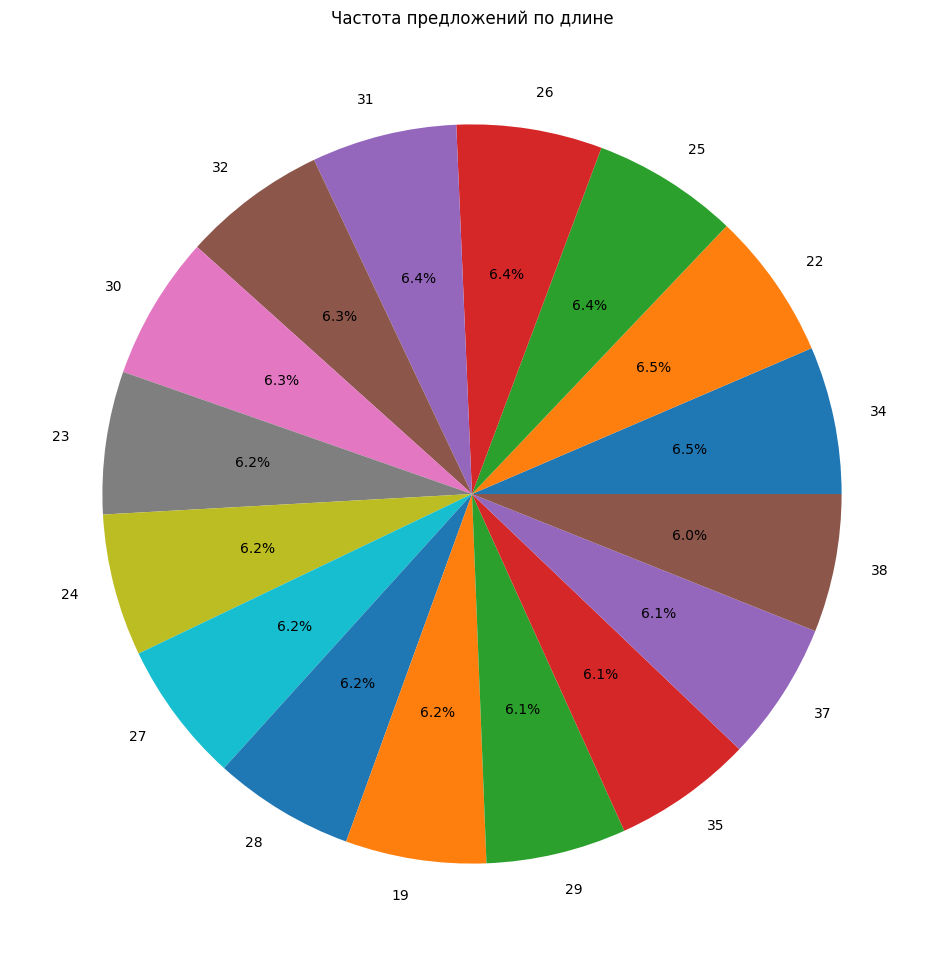

In [32]:
countLenSent = Counter()

for sent in sentence:
    countLenSent[len(sent)] += 1
    
df_countLenSent = pd.DataFrame(list(countLenSent.items()), columns=['lenght_sent', 'count'])
df_countLenSent.sort_values("count", inplace=True, ascending=False)
df_countLenSent = df_countLenSent[:16]
plt.figure(figsize=(12, 12))
plt.pie(df_countLenSent["count"].values, labels=df_countLenSent["lenght_sent"].values, colors=sns.set_color_codes("pastel"), autopct="%.1f%%")
plt.title("Частота предложений по длине")
plt.show()

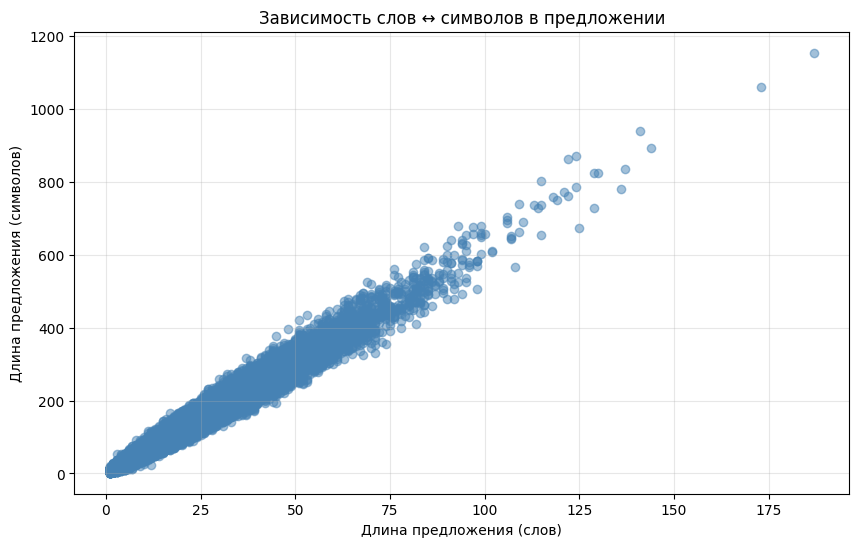

In [82]:
sentences = [sent.text.strip() for sent in doc.sents]

data = []
for sent in sentences:
    words = sent.split()
    len_words = len(words)
    len_chars = len(sent)
    data.append({
        "sentence": sent,
        "len_sentence_words": len_words,
        "len_sentence_chars": len_chars
    })

df_sents = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
plt.scatter(
    df_sents["len_sentence_words"],
    df_sents["len_sentence_chars"],
    alpha=0.5,
    color="steelblue"
)
plt.xlabel("Длина предложения (слов)")
plt.ylabel("Длина предложения (символов)")
plt.title("Зависимость слов ↔ символов в предложении")
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
cooccurrences = []
subj = []      # подлежащее
root = []      # глагол
am = []      # Определение 

for item in sentence:
    doc = Doc(item)
    doc.segment(seg)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)
      
    sent = doc.sents[0]
    tokens = list(sent.tokens)

    if len(tokens) < 3:
        continue
    
    subject = None
    predicate = None
    
    for token in tokens:
        if token.rel in ["nsubj", "nsubj:pass", "csubj", "csubj:pass", "expl"]:
            token.lemmatize(morph_lemm)
            subject = token.lemma.lower()
    
    for token in tokens:
        if token.rel in ["root", "ROOT"]:
            token.lemmatize(morph_lemm)
            predicate = token.lemma.lower()

    for token in tokens:
        if token.rel in ["amod", "nmod"]:
            token.lemmatize(morph_lemm)
            amod = token.lemma.lower()

    cooccurrences.append((subject, predicate))
    subj.append(subject)
    root.append(predicate)
    am.append(amod)

In [84]:
countCooc = Counter(cooccurrences)
countSubj = Counter(subj)
countRoot = Counter(root)
countAm = Counter(am)

cls_cooc = {pair: count for pair, count in countCooc.items() if None not in pair}
cls_subj = {key: val for key, val in countSubj.items() if None != key}
cls_root = {key: val for key, val in countRoot.items() if None != key}
cls_am = {key: val for key, val in countAm.items() if None != key}

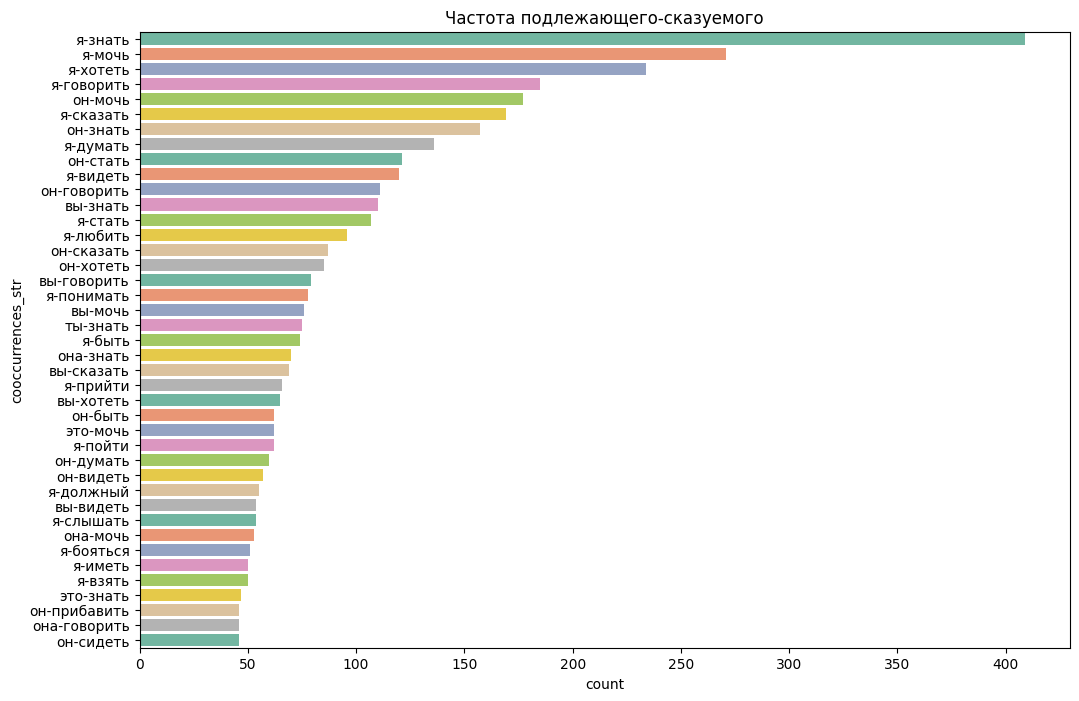

In [118]:
dfCooccurrences = pd.DataFrame(list(cls_cooc.items()), columns=['cooccurrences', 'count'])
dfCooccurrences.sort_values("count", inplace=True, ascending=False)
dfCooccurrences = dfCooccurrences.head(41)

dfCooccurrences['cooccurrences_str'] = dfCooccurrences['cooccurrences'].apply(lambda x: f"{x[0]}-{x[1]}")

plt.figure(figsize=(12, 8))
sns.barplot(x="count", y="cooccurrences_str", data=dfCooccurrences, palette='Set2', hue="cooccurrences_str", legend=False)
plt.title("Частота подлежающего-сказуемого")
plt.show()

По частоте подлежающего-сказуемого видим. Самыми популярными в нашем случае являются: "я-знать", "я-мочь", "я-хотеть"

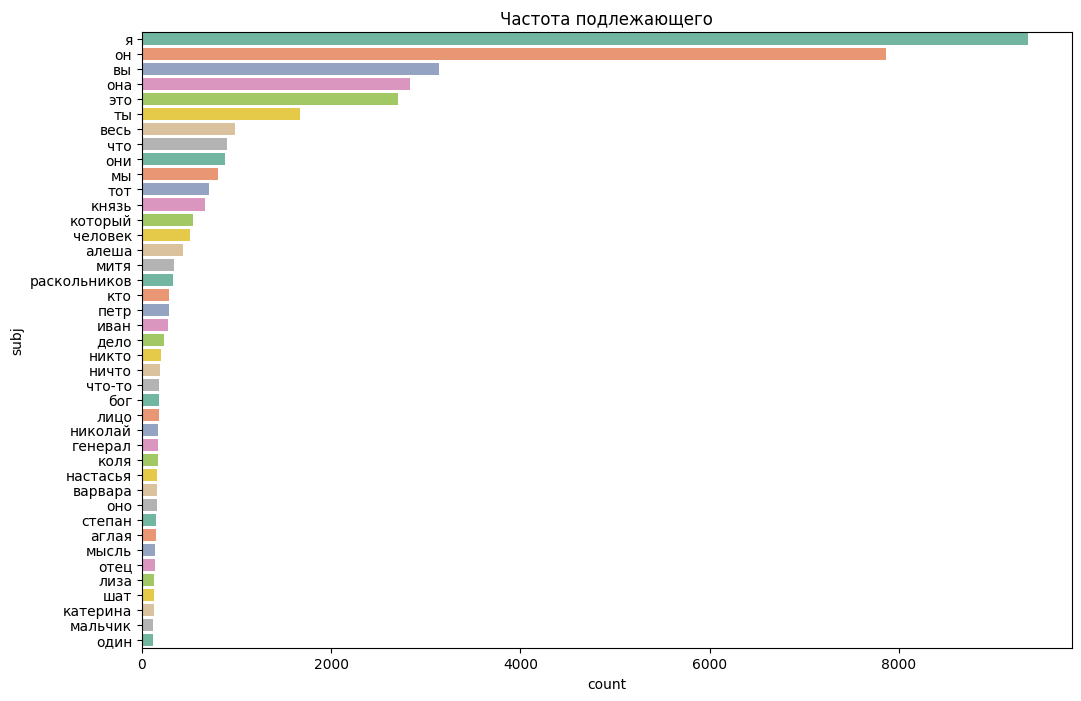

In [85]:
dfsubj = pd.DataFrame(list(cls_subj.items()), columns=['subj', 'count'])
dfsubj.sort_values("count", inplace=True, ascending=False)
dfsubj = dfsubj.head(41)

plt.figure(figsize=(12, 8))
sns.barplot(x="count", y="subj", data=dfsubj, palette='Set2', hue="subj", legend=False)
plt.title("Частота подлежающего")
plt.show()

По частоте подлежающего отметим - "я", "он", "вы"

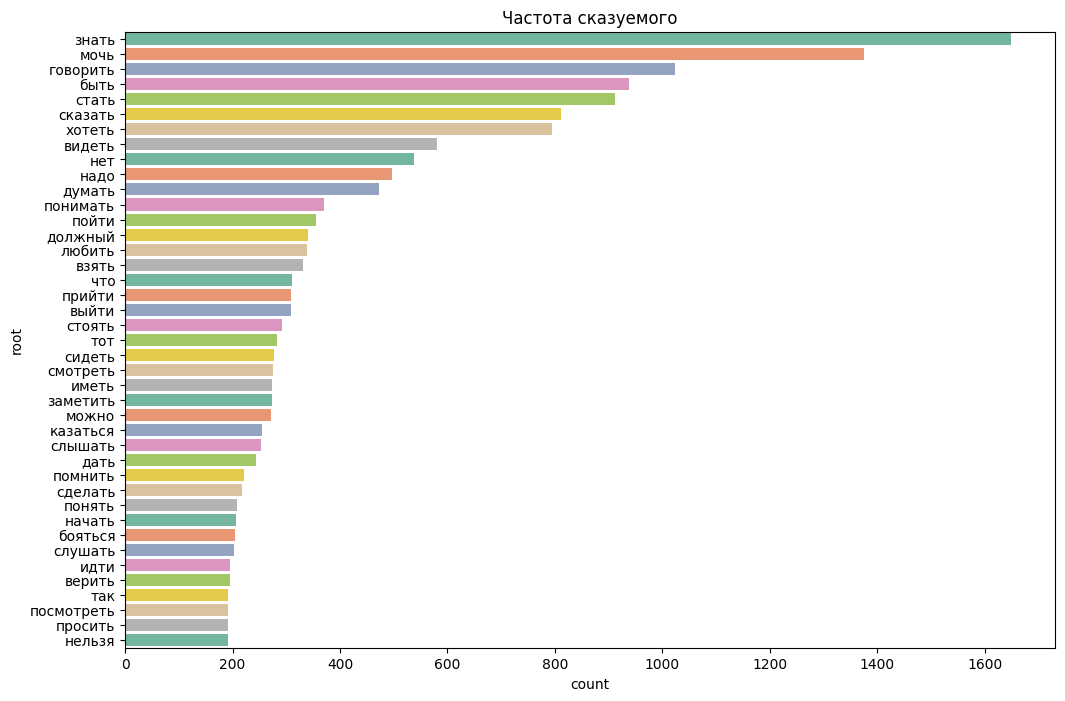

In [86]:
dfroot = pd.DataFrame(list(cls_root.items()), columns=['root', 'count'])
dfroot.sort_values("count", inplace=True, ascending=False)
dfroot = dfroot.head(41)

plt.figure(figsize=(12, 8))
sns.barplot(x="count", y="root", data=dfroot, palette='Set2', hue="root", legend=False)
plt.title("Частота сказуемого")
plt.show()

По частоте сказуемого - "знать", "мочь", "говорить"

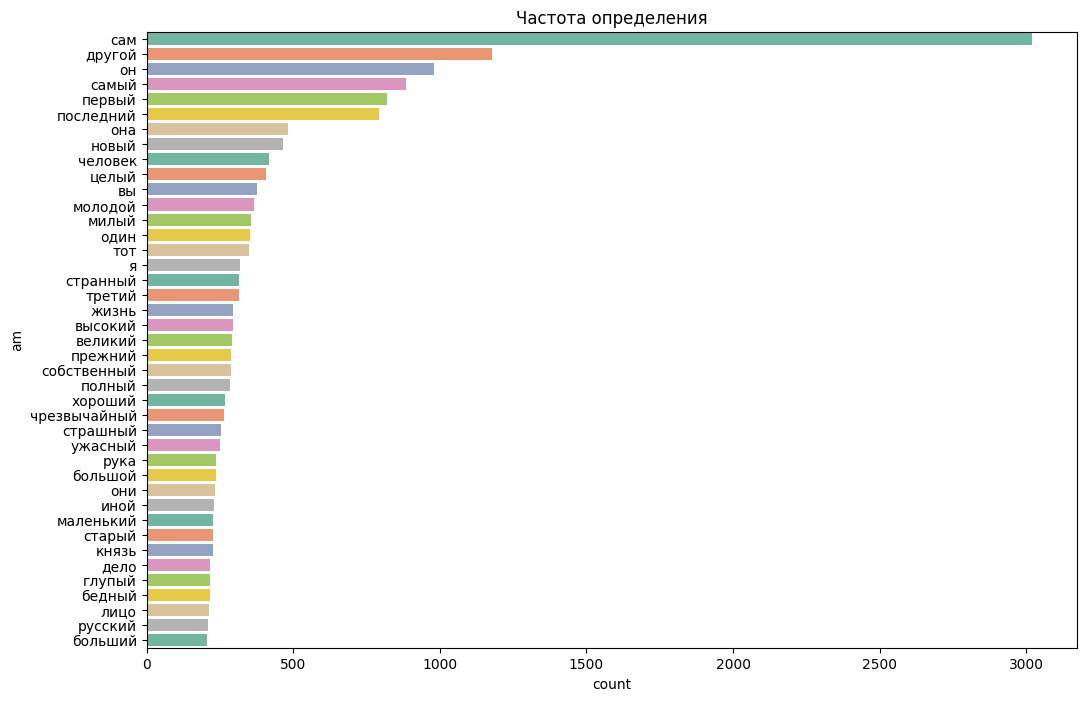

In [87]:
dfam = pd.DataFrame(list(cls_am.items()), columns=['am', 'count'])
dfam.sort_values("count", inplace=True, ascending=False)
dfam = dfam.head(41)

plt.figure(figsize=(12, 8))
sns.barplot(x="count", y="am", data=dfam, palette='Set2', hue="am", legend=False)
plt.title("Частота определения")
plt.show()

По прилагательным - "другой", "самый", "первый"

In [45]:
pattern = r'[а-яА-Я]+'
regexSentence = [re.findall(pattern, sent) for sent in sentence]

STOP_WORDS = set(stopwords.words('russian'))
clsSentence = []

for sent in regexSentence:
    sentL = []
    for word in sent:
        if word.lower() not in STOP_WORDS:
            sentL.append(word)
    clsSentence.append(' '.join(sentL))

In [57]:
cooccurrencesW = []

for item in clsSentence:
    doc = Doc(item)
    doc.segment(seg)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)

    if not doc.sents:
        continue
        
    sent = doc.sents[0]
    tokens = list(sent.tokens)

    if len(tokens) < 3:
        continue
    
    subject = None
    predicate = None
    
    for token in tokens:
        if token.rel in ["nsubj", "nsubj:pass", "csubj", "csubj:pass", "expl"]:
            token.lemmatize(morph_lemm)
            subject = token.lemma.lower()
    
    for token in tokens:
        if token.rel in ["root", "ROOT"]:
            token.lemmatize(morph_lemm)
            predicate = token.lemma.lower()
    if subject != None and predicate != None:
        cooccurrencesW.append((subject, predicate))

In [61]:
count_cooccurrencesW = Counter(cooccurrencesW)

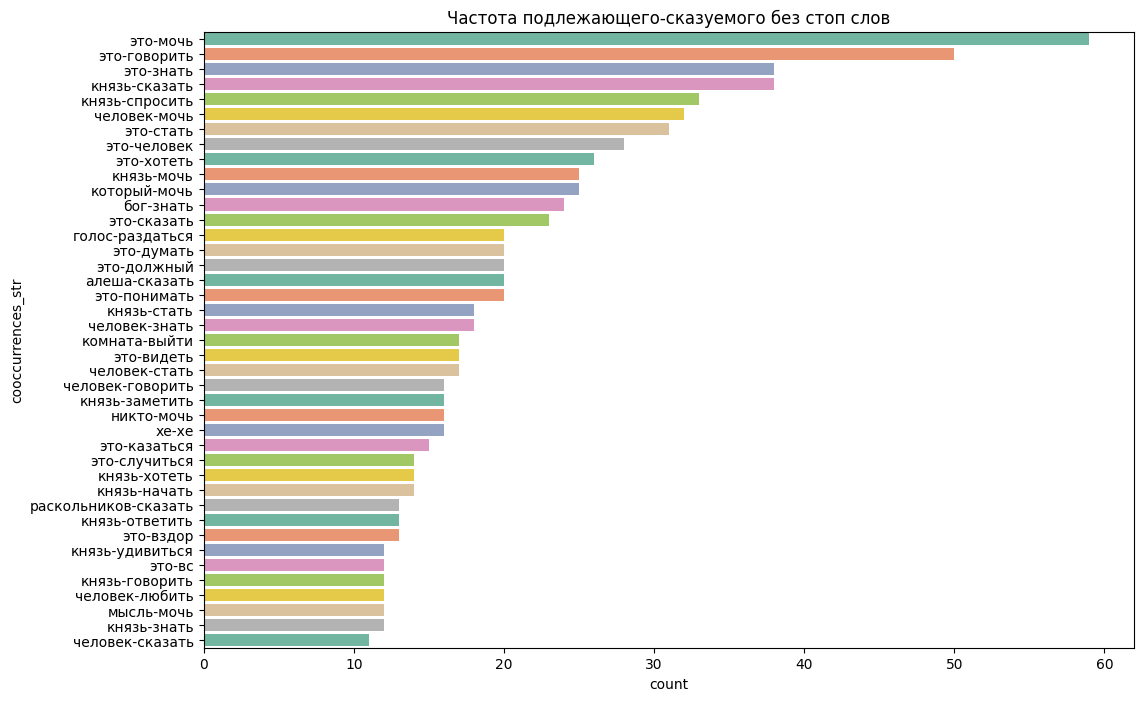

In [62]:
dfCooccurrencesW = pd.DataFrame(list(count_cooccurrencesW.items()), columns=['cooccurrences', 'count'])
dfCooccurrencesW.sort_values("count", inplace=True, ascending=False)
dfCooccurrencesW = dfCooccurrencesW.head(41)

dfCooccurrencesW['cooccurrences_str'] = dfCooccurrencesW['cooccurrences'].apply(lambda x: f"{x[0]}-{x[1]}")

plt.figure(figsize=(12, 8))
sns.barplot(x="count", y="cooccurrences_str", data=dfCooccurrencesW, palette='Set2', hue="cooccurrences_str", legend=False)
plt.title("Частота подлежающего-сказуемого без стоп слов")
plt.show()

И по частоте подлежающего-сказуемого без стоп слов - "это-мочь", "это-говорить", "это-знать", "князь-сказать", "князь-спросить"

## Self-Byte-Pair-Encoding

In [9]:
corpus = text.split()

In [13]:
tiktok = BPETok(num_merges=10)
tiktok.fit(corpus)

In [14]:
tiktok.get_size_vocab

94

In [15]:
tiktok.get_vocab

{'!',
 '"',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 ':',
 ';',
 '?',
 '«',
 '»',
 'А',
 'Б',
 'В',
 'Г',
 'Д',
 'Е',
 'Ж',
 'З',
 'И',
 'К',
 'Л',
 'М',
 'Н',
 'О',
 'П',
 'Р',
 'С',
 'Т',
 'У',
 'Ф',
 'Х',
 'Ц',
 'Ч',
 'Ш',
 'Щ',
 'Ъ',
 'Ь',
 'Э',
 'Ю',
 'Я',
 'а',
 'ал',
 'б',
 'в',
 'г',
 'го',
 'д',
 'е',
 'ж',
 'з',
 'и',
 'й',
 'к',
 'ко',
 'л',
 'м',
 'н',
 'на',
 'не',
 'но',
 'о',
 'п',
 'по',
 'р',
 'ро',
 'с',
 'ст',
 'т',
 'то',
 'у',
 'ф',
 'х',
 'ц',
 'ч',
 'ш',
 'щ',
 'ъ',
 'ы',
 'ь',
 'э',
 'ю',
 'я',
 'ё',
 '–',
 '—',
 '’',
 '“',
 '”',
 '„',
 '…',
 '№'}

На собственном алгоритме с 10 мерджами, получились следующие новые токены: 
- "ал",
- "го",
- "ко",
- "на",
- "не",
- "но",
- "по",
- "ро",
- "ст",
- "то"

## BPE

In [8]:
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))

trainer = trainers.BpeTrainer(vocab_size=100, special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])

In [9]:
tokenizer.pre_tokenizer = Whitespace()

In [14]:
tokenizer.train_from_iterator(
    sentence, 
    trainer=trainer)

In [15]:
tokenizer.get_vocab_size()

100

In [16]:
tokenizer.get_vocab()

{'?': 15,
 '(': 8,
 'ал': 99,
 'Л': 28,
 'й': 57,
 'п': 63,
 'ко': 96,
 '-': 11,
 '…': 87,
 'а': 48,
 'в': 50,
 '.': 12,
 '’': 83,
 'и': 56,
 '"': 6,
 'не': 90,
 'р': 64,
 'о': 62,
 'то': 89,
 'П': 32,
 '[CLS]': 1,
 'Ь': 44,
 'г': 51,
 'О': 31,
 'Е': 23,
 'Н': 30,
 'ст': 94,
 'Ф': 37,
 '«': 16,
 'Х': 38,
 'х': 69,
 'ц': 70,
 'т': 66,
 '[PAD]': 3,
 'У': 36,
 'Ю': 46,
 'Д': 22,
 '„': 86,
 'го': 95,
 'ы': 75,
 'ж': 54,
 'з': 55,
 'э': 77,
 '[MASK]': 4,
 'по': 93,
 '“': 84,
 'Я': 47,
 'Ш': 41,
 'С': 34,
 'Э': 45,
 'ё': 80,
 'Ъ': 43,
 'к': 58,
 'З': 25,
 '№': 88,
 'Щ': 42,
 '–': 81,
 ':': 13,
 '»': 17,
 ';': 14,
 'ъ': 74,
 'ф': 68,
 'ро': 97,
 'щ': 73,
 '”': 85,
 'ь': 76,
 ',': 10,
 'К': 27,
 '!': 5,
 '[UNK]': 0,
 'Г': 21,
 'у': 67,
 'В': 20,
 'ю': 78,
 'на': 92,
 'я': 79,
 "'": 7,
 'Ж': 24,
 'Ч': 40,
 'е': 53,
 ')': 9,
 'Б': 19,
 'н': 61,
 '—': 82,
 'л': 59,
 'А': 18,
 'Т': 35,
 'Р': 33,
 'д': 52,
 'б': 49,
 'но': 91,
 'с': 65,
 'ни': 98,
 'ш': 72,
 'Ц': 39,
 '[SEP]': 2,
 'И': 26,
 'м': 60

Получились новые токены: 
- "ал"
- "ко"
- "не"
- "ст"
- "го"
- "по"
- "ро"
- "на"
- "но"
- "ни"

In [50]:
print(tokenizer.encode("Товарищ пейс, решил не идти на бунт сегодня ночью").tokens)

['Т', 'о', 'ва', 'ри', 'щ', 'пе', 'й', 'с', ',', 'ре', 'ш', 'ил', 'не', 'и', 'д', 'ти', 'на', 'бу', 'н', 'т', 'се', 'го', 'д', 'ня', 'но', 'ч', 'ь', 'ю']


## Char-Encoding

In [9]:
tokenizer = CharTokenizer()
tokenizer.fit(text)

In [10]:
tok = tokenizer.encode("Привет, как дела?")

doc = tokenizer.decode(tok)

In [11]:
print(f"Привет, как дела? ==> Encoding ==> {tok}") 
print(f"{tok} ==> Decoding ==> {doc}")

Привет, как дела? ==> Encoding ==> [28 60 52 46 49 62  6  0 54 44 54  0 48 49 55 44 11]
[28 60 52 46 49 62  6  0 54 44 54  0 48 49 55 44 11] ==> Decoding ==> Привет, как дела?


## Data

In [13]:
seq_length = 128
chuck_size = seq_length + 1

tokenize_text = tokenizer.encode(text)
text_chunks = [tokenize_text[i:i+chuck_size]
               for i in range(len(tokenize_text) - chuck_size + 1)]

In [15]:
print(tokenizer.decode(text_chunks[1]))

лава первая Вместо введения: несколько подробностей из биографии многочтимого Степана Трофимовича Верховенского Приступая к описа


In [16]:
print(tokenizer.decode(text_chunks[2]))

ава первая Вместо введения: несколько подробностей из биографии многочтимого Степана Трофимовича Верховенского Приступая к описан


In [69]:
seq_list = []
seq_target = []

for seq in text_chunks:
    input_seq = seq[:seq_lenght]
    target = seq[seq_length]
    
    seq_list.append(input_seq)
    seq_target.append(target)

In [75]:
len(seq_list)

6588976

In [72]:
len(seq_target)

6588976

In [84]:
seq_df = pd.DataFrame(
    {
        "seq": [tokenizer.decode(arr) for arr in seq_list],
        "target": [tokenizer.decode(target) for target in seq_target]
    }
)

In [85]:
seq_df

,seq,target
0,Глава первая Вместо введения: несколько подроб...,с
1,лава первая Вместо введения: несколько подробн...,а
2,ава первая Вместо введения: несколько подробно...,н
3,ва первая Вместо введения: несколько подробнос...,и
4,а первая Вместо введения: несколько подробност...,ю
...,...,...
6588971,"вою, доселе совершенно неведомою действительно...",н
6588972,"ою, доселе совершенно неведомою действительнос...",ч
6588973,"ю, доселе совершенно неведомою действительност...",е
6588974,", доселе совершенно неведомою действительность...",н


In [88]:
seq_df["target"].value_counts()

target
     1092119
о     581932
е     457217
а     398104
и     331902
      ...   
”         29
'         23
Ь         14
№         14
Ъ          1
Name: count, Length: 85, dtype: int64

In [11]:
class SequenceDataset(Dataset):
    def __init__(self, text_chunks):
        self.text_chunks = text_chunks

    def __len__(self):
        return len(self.text_chunks)
    
    def __getitem__(self, idx):
        text_chunk = self.text_chunks[idx]
        return text_chunk[:-1].long(), text_chunk[1:].long()

In [14]:
seq_dataset = SequenceDataset(torch.tensor(text_chunks))

batch_size = 16

torch.manual_seed(1)
seq_dl = DataLoader(seq_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

C:\Users\alexs\AppData\Local\Temp\ipykernel_22036\65138526.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  seq_dataset = SequenceDataset(torch.tensor(text_chunks))


## Modeling

In [15]:
device = torch.device('cuda')

In [16]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn_hidden_size = rnn_hidden_size
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_size, vocab_size)
        
    def forward(self, x, hidden, cell):
        out = self.embedding(x).unsqueeze(1)
        out, (hidden, cell) = self.rnn(out, (hidden, cell))
        out = self.fc(out).reshape(out.size(0), -1)
        return out, hidden, cell

    def init_hidden(self, batch_size):
        hidden = torch.zeros(1, batch_size, self.rnn_hidden_size)
        cell = torch.zeros(1, batch_size, self.rnn_hidden_size)
        return hidden.to(device), cell.to(device)

vocab_size = tokenizer.get_vocab_size
embed_dim = 256
rnn_hidden_size = 512

torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size)
model = model.to(device)

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = op.Adam(model.parameters(), lr=0.005)

In [21]:
epochs = 10
history_losses = []

scaler = torch.amp.GradScaler('cuda')

for epoch in range(epochs):
    hidden, cell = model.init_hidden(batch_size)
    seq_batch, target_batch = next(iter(seq_dl))
    seq_batch = seq_batch.to(device)
    target_batch = target_batch.to(device)

    optimizer.zero_grad()
    loss = 0

    with torch.autocast(device_type='cuda', dtype=torch.float16):
        for char in range(seq_length):
            pred, hidden, cell = model(seq_batch[:, char], hidden, cell)
            loss += loss_fn(pred, target_batch[:, char])

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    
    loss = loss.item() / seq_length
    history_losses.append(loss)
    if epoch % 1 == 0:
        print(f"Epoch {epoch} loss: {round(loss, 3)}")

Epoch 0 loss: 4.438
Epoch 1 loss: 4.436
Epoch 2 loss: 4.435
Epoch 3 loss: 4.436
Epoch 4 loss: 4.435
Epoch 5 loss: 4.436
Epoch 6 loss: 3.86
Epoch 7 loss: 3.324
Epoch 8 loss: 3.309
Epoch 9 loss: 3.098


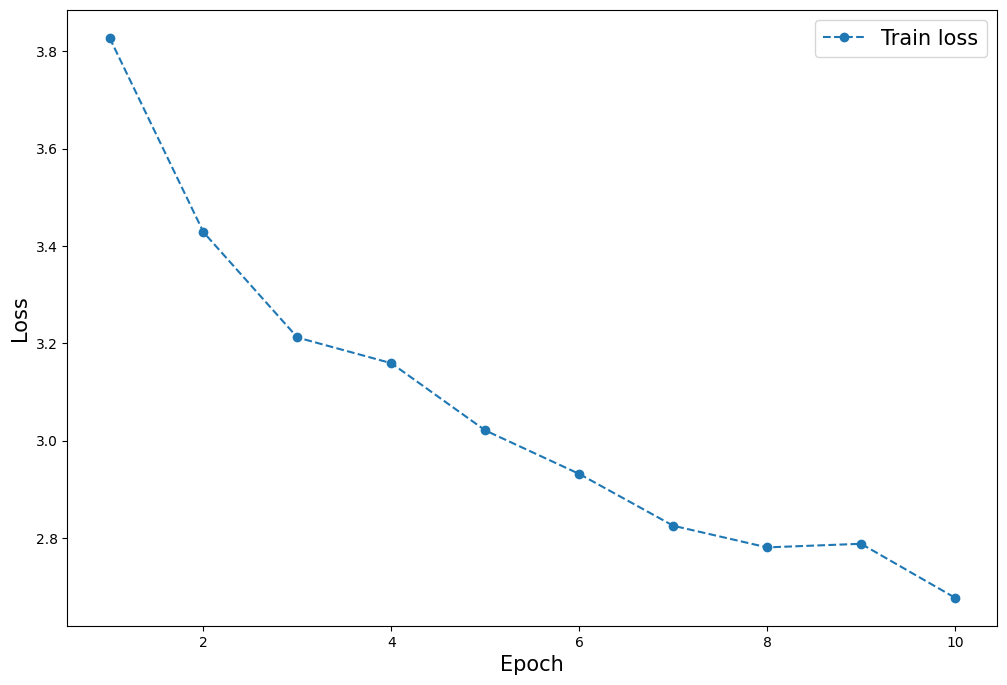

In [195]:
from utils.figure import create_figure_loss

create_figure_loss(history_losses)

In [197]:
tokenizer.encode("Hello< guys!")

KeyError: 'H'

In [174]:
save_dir = "models"

torch.save(model, os.path.join(save_dir, "model.pth"))

### Evaluate

In [176]:
model = torch.load(os.path.join(save_dir, "model.pth"))

In [148]:
def sample(model, starting_str, 
           len_generated_text=500, 
           scale_factor=1.0):

    encoded_input = torch.tensor(tokenizer.encode(starting_str))
    encoded_input = torch.reshape(encoded_input, (1, -1))

    generated_str = starting_str

    model.eval()
    hidden, cell = model.init_hidden(1)
    hidden = hidden.to('cpu')
    cell = cell.to('cpu')

    for char in range(len(starting_str) - 1):
        _, hidden, cell = model(encoded_input[:, char].view(1), hidden, cell)

    last_char = encoded_input[:, -1]
    for i in range(len_generated_text):
        logits, hidden, cell  = model(last_char.view(1), hidden, cell)
        logits = torch.squeeze(logits, 0)
        scaled_logits = logits * scale_factor
        m = Categorical(logits=scaled_logits)
        last_char = m.sample()
        generated_str += str(tokenizer.decode(last_char))

    return generated_str

In [151]:
model.to('cpu')
print(sample(model, starting_str="Привет, как дела"))

Привет, как делаЪйшёО!!АкГ:(нЧМбеОщ«(?«ъ!«Кбгф”хЗ”а»“ЬЯРМи;г«З:ЮцШ:Лмы«пккюЭгДР»ъ—ейУц—«ХёЮе))„ьяв№;ЕнгчлВАкНи”кйлП“"иж:-—”айкъХОаёпЬБР…,цаВ…Ю»ЮыЗТц?моК'Ш»щЗИэЮ"-.Ч»„"–„ЕиСТ бЭьюТбУУРл“Дю-ЪнеБДьн“ЯЭХ–—–;’юУЖ’фгРеФФВУО–см(г-ЭО«знФ“НХюУИ…Еат зФбькдчщШвАд’КВ?ЬБТл»”;Кц"НлЖЖЭ’ЭзЬйЕуИтдфЖч-»Бе’впсЯМЮ:лБ.ъма'пъхЬ((”ёЭЧЛЬзжбМ—оаУ„м«ПГ’Ъ'Щл—«щаоЮОр…;руЩнзуЧьЭУцятёй—иьГЯЗл?Ю“Бо"мЖРС«а?ЯИжб) ъКбСА’”кмЧ–ЖаПРШи–Удь„ГУКгЭЬЪОш?у.ъмгТАЛ"О?-ЧсЬвЬЗ«кжфки,,«Х;ЪЩ(САУс№«!’тгЭн“ъСф“цЭ’ЩУА”ЯЕпяайрХ—ИМхыТОэьОШ»гВБ””)аын’ОяеГЛЩКУЖЦЯ”дБ
